In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from google.colab import files
import io

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(df.shape)

Saving churn-bigml-80.csv to churn-bigml-80 (1).csv
(2666, 20)


In [8]:
df_clean = df.copy()
df_clean["International plan"] = df_clean["International plan"].map({"Yes": 1, "No": 0})
df_clean["Voice mail plan"]    = df_clean["Voice mail plan"].map({"Yes": 1, "No": 0})

# Drop high-cardinality identifiers
df_clean = df_clean.drop(columns=["State", "Area code"])

# Feature engineering
df_clean["total_minutes"] = (
    df_clean["Total day minutes"] +
    df_clean["Total eve minutes"] +
    df_clean["Total night minutes"] +
    df_clean["Total intl minutes"]
)

df_clean["total_charges"] = (
    df_clean["Total day charge"] +
    df_clean["Total eve charge"] +
    df_clean["Total night charge"] +
    df_clean["Total intl charge"]
)

df_clean["high_service_calls"] = (df_clean["Customer service calls"] >= 3).astype(int)

df_clean["intl_usage_ratio"] = (
    df_clean["Total intl minutes"] / df_clean["total_minutes"]
).fillna(0)

df_clean["account_length_group"] = pd.cut(
    df_clean["Account length"],
    bins=[0, 50, 150, df_clean["Account length"].max()],
    labels=["new", "mid", "long"]
)

# One-hot encode only account_length_group
df_clean = pd.get_dummies(df_clean, columns=["account_length_group"], drop_first=True)
df_clean = df_clean.fillna(0)

# Define X and y
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"].astype(int)

# split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train_nn = y_train_nn.values
y_test_nn  = y_test_nn.values

# Fit scaler on training data only, then apply to test
numeric_cols = X_train_nn.select_dtypes(include=["int64", "float64"]).columns
scaler = StandardScaler()
X_train_nn[numeric_cols] = scaler.fit_transform(X_train_nn[numeric_cols])
X_test_nn[numeric_cols]  = scaler.transform(X_test_nn[numeric_cols])

print(f"Training samples  : {X_train_nn.shape[0]}")
print(f"Test samples      : {X_test_nn.shape[0]}")
print(f"Number of features: {X_train_nn.shape[1]}")

Training samples  : 2132
Test samples      : 534
Number of features: 23


In [9]:
tf.keras.backend.clear_session()
input_dim = X_train_nn.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name="Churn_NN")

model.summary()

Model: "Churn_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,401 (56.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_nn)
weights = compute_class_weight(class_weight={0: 1, 1: 4}, classes=classes, y=y_train_nn)
class_weight_dict = dict(zip(classes, weights))

print("Class weights:", class_weight_dict)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(4.0)}
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4534 - auc: 0.6689 - loss: 1.0305 - val_accuracy: 0.7143 - val_auc: 0.8338 - val_loss: 0.6372
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7015 - auc: 0.7872 - loss: 0.8125 - val_accuracy: 0.8150 - val_auc: 0.8485 - val_loss: 0.5302
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7783 - auc: 0.8175 - loss: 0.7354 - val_accuracy: 0.8173 - val_auc: 0.8575 - val_loss: 0.4561
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8199 - auc: 0.8583 - loss: 0.6604 - val_accuracy: 0.8431 - val_auc: 0.8674 - val_loss: 0.3980
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8422 - auc: 0.8658 - loss: 0.6315 - val_accuracy: 0.8478 - val_auc: 0.8763 - val_loss: 0.3741
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8581 - auc: 0.8799 - loss: 0.5941 - val_accuracy: 0.8618 - val_

Test Loss     : 0.3167
Test Accuracy : 0.8858
Test AUC      : 0.8539
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Neural Network Results
Accuracy: 0.8857677902621723

              precision    recall  f1-score   support

    No Churn       0.94      0.92      0.93       456
       Churn       0.60      0.68      0.63        78

    accuracy                           0.89       534
   macro avg       0.77      0.80      0.78       534
weighted avg       0.89      0.89      0.89       534



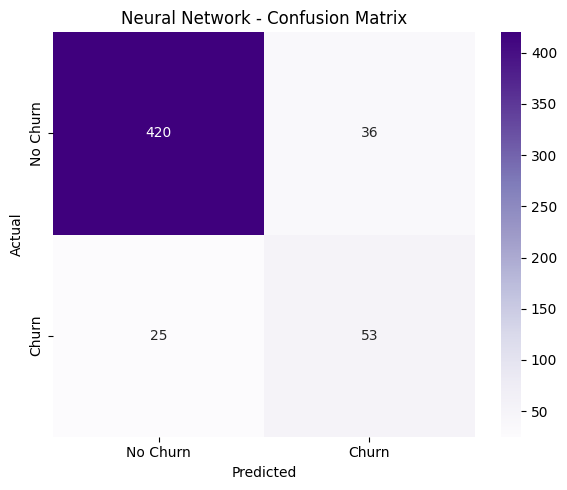

In [11]:
#Results
test_loss, test_acc, test_auc = model.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test AUC      : {test_auc:.4f}")

y_prob_nn = model.predict(X_test_nn).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("Neural Network Results")
print("Accuracy:", accuracy_score(y_test_nn, y_pred_nn))
print()
print(classification_report(y_test_nn, y_pred_nn, target_names=["No Churn", "Churn"]))

#Confusion Matrix
cm = confusion_matrix(y_test_nn, y_pred_nn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Neural Network - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

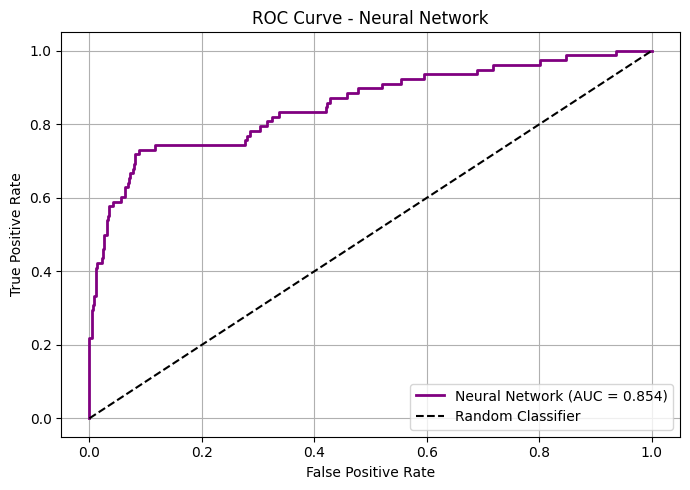

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test_nn, y_prob_nn)
auc_score   = roc_auc_score(y_test_nn, y_prob_nn)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='purple', lw=2, label=f"Neural Network (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

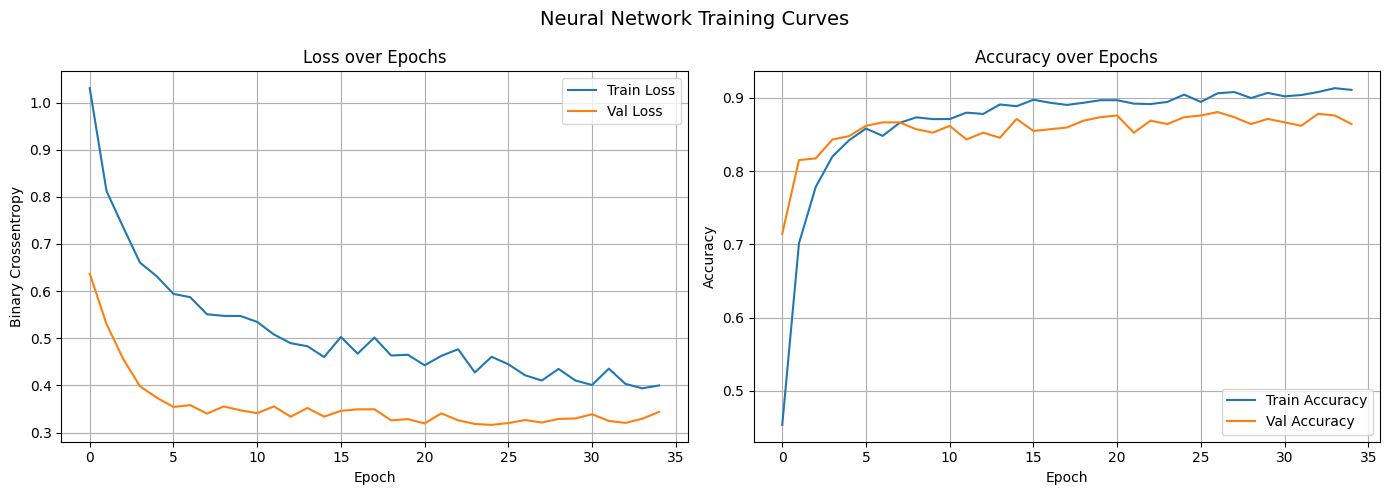

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Neural Network Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.3 MB/s eta 0:00:00


In [15]:
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))

    # Tune number of units in first layer
    model.add(layers.Dense(
        units=hp.Choice('units_1', values=[32, 64, 128]),
        activation='relu'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(
        rate=hp.Choice('dropout_1', values=[0.2, 0.3, 0.4])
    ))

    # Tune number of units in second layer
    model.add(layers.Dense(
        units=hp.Choice('units_2', values=[16, 32, 64]),
        activation='relu'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(
        rate=hp.Choice('dropout_2', values=[0.2, 0.3, 0.4])
    ))

    # Tune number of units in third layer
    model.add(layers.Dense(
        units=hp.Choice('units_3', values=[8, 16, 32]),
        activation='relu'
    ))

    model.add(layers.Dense(1, activation='sigmoid'))

    # Tune learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[0.01, 0.001, 0.0005])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

In [16]:
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=20,
    seed=42,
    directory='tuner_results',
    project_name='churn_tuning'
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

tuner.search(
    X_train_nn, y_train_nn,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0: 1, 1: 4},
    callbacks=[early_stop],
    verbose=1
)

print("Search complete!")
tuner.results_summary()

Trial 20 Complete [00h 00m 18s]
val_auc: 0.8921704292297363

Best val_auc So Far: 0.9137521982192993
Total elapsed time: 00h 05m 47s
Search complete!
Results summary
Results in tuner_results/churn_tuning
Showing 10 best trials
Objective(name="val_auc", direction="max")

Trial 07 summary
Hyperparameters:
units_1: 64
dropout_1: 0.2
units_2: 32
dropout_2: 0.3
units_3: 8
learning_rate: 0.001
Score: 0.9137521982192993

Trial 03 summary
Hyperparameters:
units_1: 32
dropout_1: 0.2
units_2: 64
dropout_2: 0.4
units_3: 32
learning_rate: 0.01
Score: 0.9089056253433228

Trial 14 summary
Hyperparameters:
units_1: 64
dropout_1: 0.4
units_2: 16
dropout_2: 0.3
units_3: 16
learning_rate: 0.01
Score: 0.9064329862594604

Trial 13 summary
Hyperparameters:
units_1: 64
dropout_1: 0.3
units_2: 32
dropout_2: 0.4
units_3: 16
learning_rate: 0.01
Score: 0.9005974531173706

Trial 09 summary
Hyperparameters:
units_1: 32
dropout_1: 0.2
units_2: 64
dropout_2: 0.4
units_3: 16
learning_rate: 0.01
Score: 0.899034678936

In [17]:
# Print best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(f"  Layer 1 units    : {best_hps.get('units_1')}")
print(f"  Layer 2 units    : {best_hps.get('units_2')}")
print(f"  Layer 3 units    : {best_hps.get('units_3')}")
print(f"  Dropout 1        : {best_hps.get('dropout_1')}")
print(f"  Dropout 2        : {best_hps.get('dropout_2')}")
print(f"  Learning Rate    : {best_hps.get('learning_rate')}")

Best Hyperparameters:
  Layer 1 units    : 64
  Layer 2 units    : 32
  Layer 3 units    : 8
  Dropout 1        : 0.2
  Dropout 2        : 0.3
  Learning Rate    : 0.001


In [18]:
#Hypertuned Model
tf.keras.backend.clear_session()

model_tuned = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(8, activation='relu'),

    layers.Dense(1, activation='sigmoid')
], name="Churn_NN_Tuned")

model_tuned.summary()

Model: "Churn_NN_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,353 (9.19 KB)

 Trainable params: 2,225 (8.69 KB)

 Non-trainable params: 128 (512.00 B)

In [19]:
model_tuned.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_tuned = model_tuned.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight={0: 1, 1: 4},
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7513 - auc: 0.7497 - loss: 0.8216 - val_accuracy: 0.8080 - val_auc: 0.8715 - val_loss: 0.4444
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8293 - auc: 0.8613 - loss: 0.6459 - val_accuracy: 0.8103 - val_auc: 0.8834 - val_loss: 0.4230
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8428 - auc: 0.8633 - loss: 0.6343 - val_accuracy: 0.8080 - val_auc: 0.8747 - val_loss: 0.4407
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8587 - auc: 0.8920 - loss: 0.5669 - val_accuracy: 0.8314 - val_auc: 0.8820 - val_loss: 0.3844
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8657 - auc: 0.8883 - loss: 0.5766 - val_accuracy: 0.8267 - val_auc: 0.8946 - val_loss: 0.4024
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8680 - auc: 0.8917 - loss: 0.5619 - val_accuracy: 0.8361 - val_auc: 0.8976 - val_loss: 0.3688
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

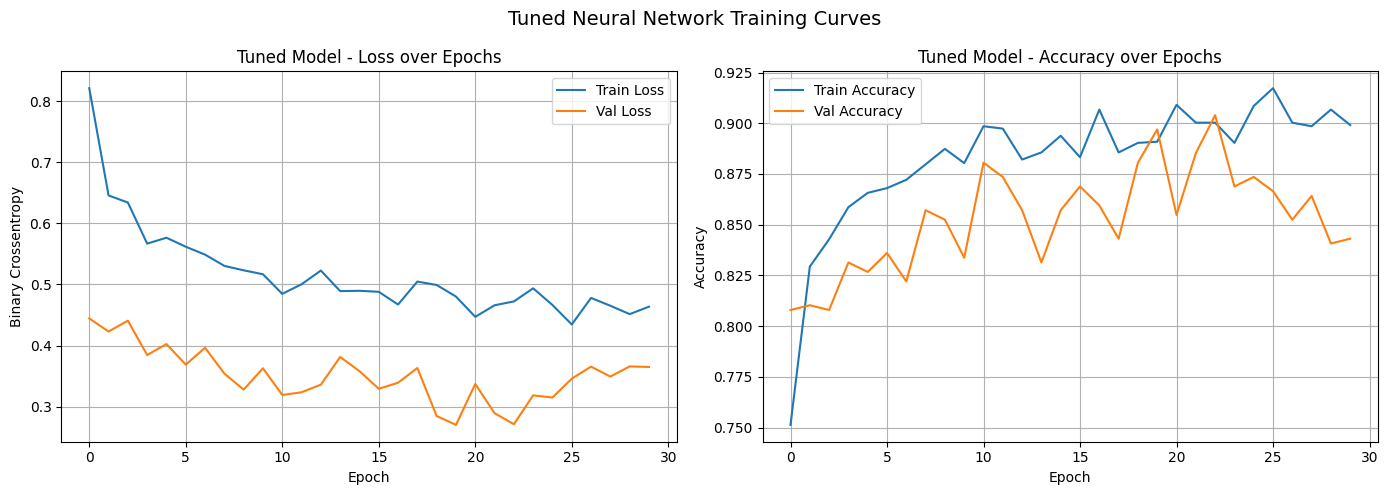

Tuned Model Test Accuracy : 0.9045
Tuned Model Test AUC      : 0.8377
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

              precision    recall  f1-score   support

    No Churn       0.94      0.95      0.94       456
       Churn       0.69      0.63      0.66        78

    accuracy                           0.90       534
   macro avg       0.81      0.79      0.80       534
weighted avg       0.90      0.90      0.90       534



In [20]:
#Results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_tuned.history['loss'],     label='Train Loss')
axes[0].plot(history_tuned.history['val_loss'], label='Val Loss')
axes[0].set_title('Tuned Model - Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_tuned.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_tuned.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Tuned Model - Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Tuned Neural Network Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

# Evaluate
test_loss, test_acc, test_auc = model_tuned.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"Tuned Model Test Accuracy : {test_acc:.4f}")
print(f"Tuned Model Test AUC      : {test_auc:.4f}")

# Predictions
y_prob_tuned = model_tuned.predict(X_test_nn).flatten()
y_pred_tuned = (y_prob_tuned >= 0.5).astype(int)

print()
print(classification_report(y_test_nn, y_pred_tuned, target_names=["No Churn", "Churn"]))

             Accuracy  F1 (Churn)
Original NN    0.8858      0.6347
Tuned NN       0.9045      0.6577


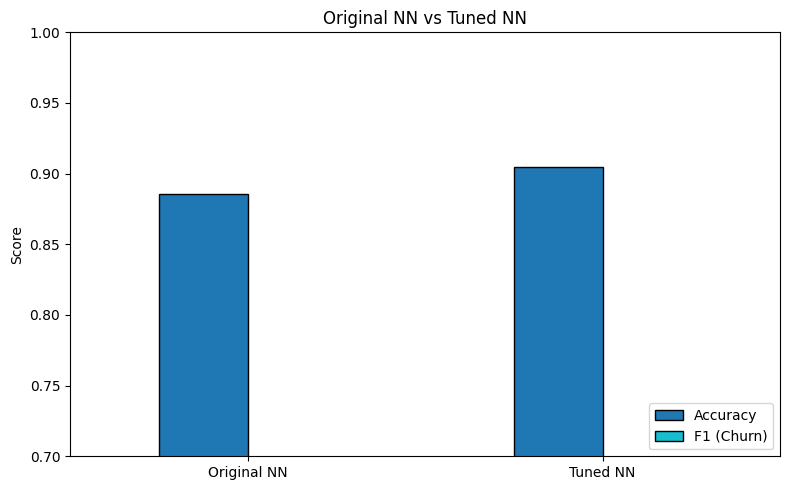

In [21]:
from sklearn.metrics import f1_score

comparison = {
    "Original NN": {
        "Accuracy":   accuracy_score(y_test_nn, y_pred_nn),
        "F1 (Churn)": f1_score(y_test_nn, y_pred_nn)
    },
    "Tuned NN": {
        "Accuracy":   accuracy_score(y_test_nn, y_pred_tuned),
        "F1 (Churn)": f1_score(y_test_nn, y_pred_tuned)
    }
}

comp_df = pd.DataFrame(comparison).T
print(comp_df.round(4))

comp_df.plot(kind='bar', figsize=(8, 5), colormap='tab10', edgecolor='black')
plt.title("Original NN vs Tuned NN")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()